# 🧴 Enhanced Cosmetic Ingredient Classificationg

## 📋 Project Overview

**Research Goal:** Develop an advanced NLP system for multi-label classification of cosmetic ingredients:

- ✅ Halal / ❌ Not Halal
- 🌱 Vegan / ❌ Not Vegan  
- 🛡️ Allergen-safe / ⚠️ Not Safe
- 🌍 Eco-friendly / ❌ Not Eco-friendly


---
## 1️⃣ Setup & Installation

In [ ]:
# Install required packages
!pip install -q transformers datasets torch torchvision torchaudio
!pip install -q scikit-learn pandas numpy matplotlib seaborn
!pip install -q networkx plotly
!pip install -q accelerate sentencepiece protobuf

print("✅ All packages installed successfully!")

✅ All packages installed successfully!


In [ ]:
# Import libraries
import os
import re
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from typing import Dict, List, Tuple, Any
import networkx as nx

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

# Transformers
from transformers import AutoTokenizer, AutoModel
from transformers import get_linear_schedule_with_warmup

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc, precision_recall_curve,
    f1_score, precision_score, recall_score
)

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

# Set random seeds
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🖥️  Using device: {device}")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")

🖥️  Using device: cpu


---
## 2️⃣ Data Loading & Exploration

In [ ]:
# Dataset loading from Google Drive
import os
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Dataset path in Google Drive
DATASET_PATH = "/content/drive/My Drive/Colab Notebooks/FYP/datasets/dataset_sephora.csv"

if os.path.exists(DATASET_PATH):
    print(f"✅ Dataset found at: {DATASET_PATH}")
    dataset_filename = DATASET_PATH
else:
    print(f"❌ Dataset not found at: {DATASET_PATH}")
    print("\n📤 Please upload your dataset to Google Drive:")
    print(f"   Path: MyDrive/Colab Notebooks/FYP/datasets/dataset_sephora.csv")
    print("\nOr use the file upload widget below:")

    from google.colab import files
    print("\n⬆️  Click 'Choose Files' to upload your dataset:")
    uploaded = files.upload()

    if uploaded:
        dataset_filename = list(uploaded.keys())[0]
        print(f"✅ Dataset uploaded: {dataset_filename}")
    else:
        raise FileNotFoundError("No dataset provided. Please upload the dataset to continue.")


Mounted at /content/drive
✅ Dataset found at: /content/drive/My Drive/Colab Notebooks/FYP/datasets/dataset_sephora.csv


In [ ]:
# Load and explore dataset
df = pd.read_csv(dataset_filename)

print(f"📊 Dataset Shape: {df.shape}")
print(f"\n📋 Columns: {df.columns.tolist()}")
print(f"\n🔍 First few rows:")
display(df.head())

print(f"\n📈 Label Distribution:")
label_cols = ['halal_label', 'vegan_label', 'allergen_label', 'eco_label']
for col in label_cols:
    if col in df.columns:
        print(f"\n{col}:")
        print(df[col].value_counts())

📊 Dataset Shape: (1472, 9)

📋 Columns: ['ingredients', 'halal_label', 'halal_trigger', 'vegan_label', 'vegan_trigger', 'allergen_label', 'allergen_trigger', 'eco_label', 'eco_trigger']

🔍 First few rows:


,ingredients,halal_label,halal_trigger,vegan_label,vegan_trigger,allergen_label,allergen_trigger,eco_label,eco_trigger
0,"Algae (Seaweed) Extract, Mineral Oil, Petrolat...",Not Halal,"['alcohol denat', 'lanolin']",Not Vegan,['lanolin'],Not Safe,"['fragrance', 'limonene', 'linalool', 'citral']",Not Eco-friendly,"['petrolatum', 'paraffin']"
1,"Galactomyces Ferment Filtrate (Pitera), Butyle...",Halal,[],Vegan,[],Safe,[],Eco-friendly,[]
2,"Water, Dicaprylyl Carbonate, Glycerin, Ceteary...",Not Halal,"['ethanol', 'oleic acid']",Vegan,[],Safe,[],Eco-friendly,[]
3,"Algae (Seaweed) Extract, Cyclopentasiloxane, P...",Not Halal,['ethanol'],Vegan,[],Not Safe,"['fragrance', 'limonene', 'linalool']",Not Eco-friendly,"['siloxane', 'petrolatum', 'paraffin']"
4,"Water, Snail Secretion Filtrate, Phenyl Trimet...",Not Halal,"['ethanol', 'collagen', 'stearic acid']",Not Vegan,"['honey', 'collagen', 'stearic acid']",Safe,[],Not Eco-friendly,['siloxane']



📈 Label Distribution:

halal_label:
halal_label
Not Halal    987
Halal        485
Name: count, dtype: int64

vegan_label:
vegan_label
Vegan        1082
Not Vegan     390
Name: count, dtype: int64

allergen_label:
allergen_label
Safe        832
Not Safe    640
Name: count, dtype: int64

eco_label:
eco_label
Eco-friendly        1155
Not Eco-friendly     317
Name: count, dtype: int64


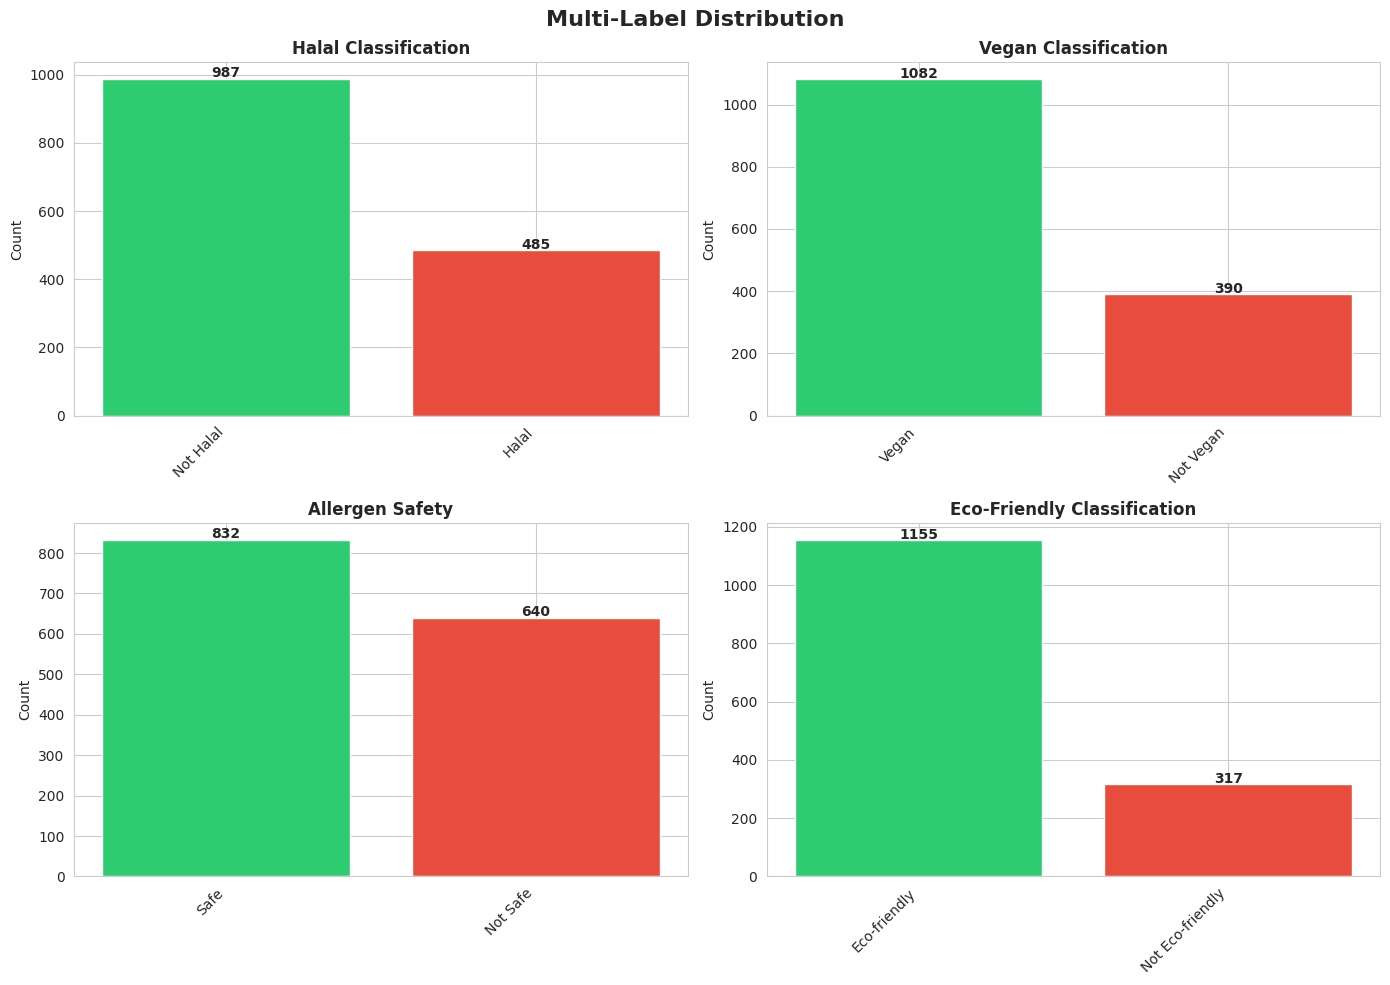

In [ ]:
# Visualize label distribution
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Multi-Label Distribution', fontsize=16, fontweight='bold')

label_names = {
    'halal_label': 'Halal Classification',
    'vegan_label': 'Vegan Classification',
    'allergen_label': 'Allergen Safety',
    'eco_label': 'Eco-Friendly Classification'
}

for idx, (col, title) in enumerate(label_names.items()):
    ax = axes[idx // 2, idx % 2]
    if col in df.columns:
        counts = df[col].value_counts()
        ax.bar(range(len(counts)), counts.values, color=['#2ecc71', '#e74c3c', '#f39c12'])
        ax.set_title(title, fontweight='bold')
        ax.set_ylabel('Count')
        ax.set_xticks(range(len(counts)))
        ax.set_xticklabels(counts.index, rotation=45, ha='right')

        for i, v in enumerate(counts.values):
            ax.text(i, v + 5, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

---
## 3️⃣ Knowledge Graph Construction

### 🧠 Novel Contribution: Ingredient Ontology

We build a knowledge graph storing:
- Ingredient names and synonyms
- Chemical classifications
- Source information (animal/plant/synthetic)
- Safety properties (halal, vegan, allergen, eco scores)

In [ ]:
# Enhanced ingredient knowledge base with 60+ ingredients
INGREDIENT_KNOWLEDGE_BASE = {
    # Animal-derived ingredients
    'lanolin': {
        'synonyms': ['wool grease', 'wool wax', 'wool fat', 'lanolin alcohol'],
        'chemical_class': 'wax_ester',
        'source': 'animal',
        'halal': 0, 'vegan': 0, 'allergen': 0.9, 'eco': 0.2,
        'reasoning': 'Derived from sheep wool; not vegan, strong allergen'
    },
    'collagen': {
        'synonyms': ['hydrolyzed collagen', 'collagen peptides', 'vegetable collagen'],
        'chemical_class': 'protein',
        'source': 'animal',
        'halal': 0.3, 'vegan': 0, 'allergen': 0.2, 'eco': 0.2,
        'reasoning': 'Animal protein; marine-derived may be halal but still not vegan'
    },
    'beeswax': {
        'synonyms': ['cera alba', 'white wax', 'cera flava'],
        'chemical_class': 'wax',
        'source': 'animal',
        'halal': 1, 'vegan': 0, 'allergen': 0.1, 'eco': 0.8,
        'reasoning': 'Bee product; halal but not vegan, sustainable'
    },
    'honey': {
        'synonyms': ['mel', 'bee honey', 'honey extract'],
        'chemical_class': 'natural_sweetener',
        'source': 'animal',
        'halal': 1, 'vegan': 0, 'allergen': 0.2, 'eco': 0.8,
        'reasoning': 'Bee product; halal but not vegan'
    },
    'carmine': {
        'synonyms': ['cochineal', 'ci 75470', 'natural red 4'],
        'chemical_class': 'colorant',
        'source': 'animal',
        'halal': 0, 'vegan': 0, 'allergen': 0.3, 'eco': 0.3,
        'reasoning': 'Derived from insects; not halal or vegan'
    },
    'keratin': {
        'synonyms': ['hydrolyzed keratin'],
        'chemical_class': 'protein',
        'source': 'animal',
        'halal': 0.2, 'vegan': 0, 'allergen': 0.1, 'eco': 0.2,
        'reasoning': 'Animal protein from hair/feathers; not vegan'
    },
    'gelatin': {
        'synonyms': ['gelatine'],
        'chemical_class': 'protein',
        'source': 'animal',
        'halal': 0.1, 'vegan': 0, 'allergen': 0.1, 'eco': 0.2,
        'reasoning': 'From animal bones/skin; usually not halal or vegan'
    },
    'snail mucin': {
        'synonyms': ['snail secretion filtrate', 'snail slime'],
        'chemical_class': 'protein',
        'source': 'animal',
        'halal': 0.7, 'vegan': 0, 'allergen': 0.2, 'eco': 0.6,
        'reasoning': 'From snails; not vegan but may be halal'
    },
    'propolis': {
        'synonyms': ['propolis extract'],
        'chemical_class': 'resin',
        'source': 'animal',
        'halal': 1, 'vegan': 0, 'allergen': 0.3, 'eco': 0.8,
        'reasoning': 'Bee product; halal but not vegan'
    },

    # Plant-derived ingredients
    'shea butter': {
        'synonyms': ['butyrospermum parkii', 'karite butter'],
        'chemical_class': 'plant_oil',
        'source': 'plant',
        'halal': 1, 'vegan': 1, 'allergen': 0.05, 'eco': 0.9,
        'reasoning': 'Plant-based, sustainable, very safe'
    },
    'coconut oil': {
        'synonyms': ['cocos nucifera oil', 'copra oil'],
        'chemical_class': 'plant_oil',
        'source': 'plant',
        'halal': 1, 'vegan': 1, 'allergen': 0.3, 'eco': 0.8,
        'reasoning': 'Plant oil; potential tree nut allergen'
    },
    'aloe vera': {
        'synonyms': ['aloe barbadensis', 'aloe vera gel', 'aloe barbadensis leaf extract', 'aloe barbadensis leaf juice'],
        'chemical_class': 'plant_extract',
        'source': 'plant',
        'halal': 1, 'vegan': 1, 'allergen': 0.1, 'eco': 0.95,
        'reasoning': 'Natural plant extract; very safe'
    },
    'jojoba oil': {
        'synonyms': ['simmondsia chinensis', 'jojoba seed oil'],
        'chemical_class': 'plant_oil',
        'source': 'plant',
        'halal': 1, 'vegan': 1, 'allergen': 0.05, 'eco': 0.9,
        'reasoning': 'Plant-based liquid wax; very safe'
    },
    'argan oil': {
        'synonyms': ['argania spinosa oil'],
        'chemical_class': 'plant_oil',
        'source': 'plant',
        'halal': 1, 'vegan': 1, 'allergen': 0.1, 'eco': 0.85,
        'reasoning': 'Plant oil; safe and sustainable'
    },
    'tea tree oil': {
        'synonyms': ['melaleuca alternifolia oil'],
        'chemical_class': 'essential_oil',
        'source': 'plant',
        'halal': 1, 'vegan': 1, 'allergen': 0.4, 'eco': 0.9,
        'reasoning': 'Essential oil; can irritate sensitive skin'
    },
    'rose water': {
        'synonyms': ['rosa damascena water', 'rose hydrosol'],
        'chemical_class': 'plant_extract',
        'source': 'plant',
        'halal': 1, 'vegan': 1, 'allergen': 0.2, 'eco': 0.9,
        'reasoning': 'Natural extract; generally safe'
    },
    'green tea extract': {
        'synonyms': ['camellia sinensis extract', 'camellia sinensis leaf extract'],
        'chemical_class': 'plant_extract',
        'source': 'plant',
        'halal': 1, 'vegan': 1, 'allergen': 0.1, 'eco': 0.9,
        'reasoning': 'Antioxidant extract; safe'
    },
    'chamomile extract': {
        'synonyms': ['chamomilla recutita extract', 'anthemis nobilis flower extract'],
        'chemical_class': 'plant_extract',
        'source': 'plant',
        'halal': 1, 'vegan': 1, 'allergen': 0.2, 'eco': 0.9,
        'reasoning': 'Soothing extract; generally safe'
    },
    'vitamin c': {
        'synonyms': ['ascorbic acid', 'l-ascorbic acid', '3-o-ethyl ascorbic acid'],
        'chemical_class': 'vitamin',
        'source': 'plant',
        'halal': 1, 'vegan': 1, 'allergen': 0.15, 'eco': 0.9,
        'reasoning': 'Plant-derived antioxidant; safe'
    },
    'marula oil': {
        'synonyms': ['sclerocarya birrea seed oil'],
        'chemical_class': 'plant_oil',
        'source': 'plant',
        'halal': 1, 'vegan': 1, 'allergen': 0.05, 'eco': 0.9,
        'reasoning': 'Plant-based oil; very safe'
    },

    # Ambiguous but treating as PLANT-BASED per your dataset
    'glycerin': {
        'synonyms': ['glycerol', 'glycerine'],
        'chemical_class': 'alcohol',
        'source': 'plant',  # Changed from ambiguous to plant
        'halal': 1, 'vegan': 1, 'allergen': 0.02, 'eco': 0.6,  # Changed from 0.5 to 1
        'reasoning': 'Assuming plant-based (from palm/soy); halal and vegan in this dataset'
    },

    # Ambiguous - NOT halal/vegan per your dataset
    'stearic acid': {
        'synonyms': ['octadecanoic acid', 'stearate', 'magnesium stearate', 'calcium stearate'],
        'chemical_class': 'fatty_acid',
        'source': 'ambiguous',
        'halal': 0, 'vegan': 0, 'allergen': 0.05, 'eco': 0.5,  # Changed from 0.5 to 0
        'reasoning': 'Ambiguous source (animal/plant); treating as not halal/vegan per dataset'
    },
    'oleic acid': {
        'synonyms': ['decyl oleate', 'sorbitan oleate'],
        'chemical_class': 'fatty_acid',
        'source': 'ambiguous',
        'halal': 0, 'vegan': 0.5, 'allergen': 0.05, 'eco': 0.5,  # NEW: halal=0
        'reasoning': 'Fatty acid; can be animal/plant-derived; not halal per dataset'
    },
    'squalene': {
        'synonyms': ['squalane'],
        'chemical_class': 'lipid',
        'source': 'ambiguous',
        'halal': 0.5, 'vegan': 0, 'allergen': 0.02, 'eco': 0.5,  # NEW: vegan=0
        'reasoning': 'Can be shark-derived (not vegan) or plant-derived; ambiguous halal'
    },
    'lecithin': {
        'synonyms': ['soy lecithin', 'phosphatidylcholine'],
        'chemical_class': 'phospholipid',
        'source': 'ambiguous',
        'halal': 0.6, 'vegan': 0.6, 'allergen': 0.3, 'eco': 0.7,
        'reasoning': 'Usually soy-based but can be from eggs'
    },
    'ceramide': {
        'synonyms': ['ceramide np', 'ceramide ap'],
        'chemical_class': 'lipid',
        'source': 'ambiguous',
        'halal': 0.5, 'vegan': 0.5, 'allergen': 0.05, 'eco': 0.6,
        'reasoning': 'Can be plant, animal, or synthetic'
    },
    'palmitic acid': {
        'synonyms': ['hexadecanoic acid'],
        'chemical_class': 'fatty_acid',
        'source': 'ambiguous',
        'halal': 0.5, 'vegan': 0.5, 'allergen': 0.05, 'eco': 0.4,
        'reasoning': 'From palm oil or animal sources'
    },

    # Synthetic/Lab-made ingredients
    'dimethicone': {
        'synonyms': ['polydimethylsiloxane', 'pdms'],
        'chemical_class': 'silicone',
        'source': 'synthetic',
        'halal': 1, 'vegan': 1, 'allergen': 0.02, 'eco': 0.2,
        'reasoning': 'Synthetic silicone; not biodegradable'
    },
    'cyclopentasiloxane': {
        'synonyms': ['d5', 'cyclomethicone', 'cyclohexasiloxane'],
        'chemical_class': 'silicone',
        'source': 'synthetic',
        'halal': 1, 'vegan': 1, 'allergen': 0.02, 'eco': 0.15,
        'reasoning': 'Volatile silicone; environmental concerns'
    },
    'parabens': {
        'synonyms': ['methylparaben', 'propylparaben', 'butylparaben'],
        'chemical_class': 'preservative',
        'source': 'synthetic',
        'halal': 1, 'vegan': 1, 'allergen': 0.4, 'eco': 0.2,
        'reasoning': 'Synthetic preservative; controversial'
    },
    'phenoxyethanol': {
        'synonyms': ['phenoxetol'],
        'chemical_class': 'preservative',
        'source': 'synthetic',
        'halal': 1, 'vegan': 1, 'allergen': 0.25, 'eco': 0.4,
        'reasoning': 'Synthetic preservative; potential irritant'
    },
    'sodium lauryl sulfate': {
        'synonyms': ['sls', 'sodium dodecyl sulfate'],
        'chemical_class': 'surfactant',
        'source': 'synthetic',
        'halal': 1, 'vegan': 1, 'allergen': 0.6, 'eco': 0.3,
        'reasoning': 'Harsh surfactant; can irritate'
    },
    'sodium laureth sulfate': {
        'synonyms': ['sles'],
        'chemical_class': 'surfactant',
        'source': 'synthetic',
        'halal': 1, 'vegan': 1, 'allergen': 0.4, 'eco': 0.3,
        'reasoning': 'Milder than SLS but still potential irritant'
    },
    'peg compounds': {
        'synonyms': ['polyethylene glycol', 'peg-100', 'peg-8', 'peg-9', 'peg-40', 'peg-75', 'peg/ppg'],
        'chemical_class': 'polymer',
        'source': 'synthetic',
        'halal': 1, 'vegan': 1, 'allergen': 0.3, 'eco': 0.3,
        'reasoning': 'Synthetic polymers; environmental concerns'
    },
    'petrolatum': {
        'synonyms': ['petroleum jelly', 'mineral oil jelly'],
        'chemical_class': 'petroleum_derivative',
        'source': 'synthetic',
        'halal': 1, 'vegan': 1, 'allergen': 0.05, 'eco': 0.1,
        'reasoning': 'Petroleum-based; not eco-friendly'
    },
    'mineral oil': {
        'synonyms': ['paraffinum liquidum', 'liquid paraffin'],
        'chemical_class': 'petroleum_derivative',
        'source': 'synthetic',
        'halal': 1, 'vegan': 1, 'allergen': 0.05, 'eco': 0.1,
        'reasoning': 'Petroleum-based; not biodegradable'
    },
    'paraffin': {
        'synonyms': ['paraffin wax', 'isohexadecane', 'isoparaffin'],
        'chemical_class': 'petroleum_derivative',
        'source': 'synthetic',
        'halal': 1, 'vegan': 1, 'allergen': 0.05, 'eco': 0.1,
        'reasoning': 'Petroleum-based wax; not eco-friendly'
    },

    # Allergen-prone ingredients
    'fragrance': {
        'synonyms': ['parfum', 'perfume'],
        'chemical_class': 'fragrance',
        'source': 'ambiguous',
        'halal': 0.5, 'vegan': 0.5, 'allergen': 0.95, 'eco': 0.3,
        'reasoning': 'Mixed ingredients; major allergen'
    },
    'limonene': {
        'synonyms': ['d-limonene'],
        'chemical_class': 'terpene',
        'source': 'plant',
        'halal': 1, 'vegan': 1, 'allergen': 0.7, 'eco': 0.9,
        'reasoning': 'Natural; can cause allergies when oxidized'
    },
    'linalool': {
        'synonyms': ['linalyl alcohol'],
        'chemical_class': 'terpene_alcohol',
        'source': 'plant',
        'halal': 1, 'vegan': 1, 'allergen': 0.65, 'eco': 0.9,
        'reasoning': 'Natural fragrance; potential allergen'
    },
    'citral': {
        'synonyms': ['lemonal'],
        'chemical_class': 'terpene',
        'source': 'plant',
        'halal': 1, 'vegan': 1, 'allergen': 0.6, 'eco': 0.9,
        'reasoning': 'Citrus fragrance; potential allergen'
    },
    'geraniol': {
        'synonyms': [],
        'chemical_class': 'terpene_alcohol',
        'source': 'plant',
        'halal': 1, 'vegan': 1, 'allergen': 0.6, 'eco': 0.9,
        'reasoning': 'Floral fragrance; potential allergen'
    },
    'eugenol': {
        'synonyms': [],
        'chemical_class': 'phenylpropanoid',
        'source': 'plant',
        'halal': 1, 'vegan': 1, 'allergen': 0.65, 'eco': 0.9,
        'reasoning': 'Spice fragrance; potential allergen'
    },
    'cinnamal': {
        'synonyms': ['cinnamaldehyde'],
        'chemical_class': 'aldehyde',
        'source': 'plant',
        'halal': 1, 'vegan': 1, 'allergen': 0.7, 'eco': 0.85,
        'reasoning': 'Cinnamon fragrance; known allergen'
    },
    'citronellol': {
        'synonyms': [],
        'chemical_class': 'terpene_alcohol',
        'source': 'plant',
        'halal': 1, 'vegan': 1, 'allergen': 0.6, 'eco': 0.9,
        'reasoning': 'Natural fragrance; potential allergen'
    },

    # Vitamins and active ingredients
    'hyaluronic acid': {
        'synonyms': ['sodium hyaluronate', 'hyaluronan', 'hydrolyzed hyaluronic acid'],
        'chemical_class': 'polysaccharide',
        'source': 'synthetic',
        'halal': 1, 'vegan': 1, 'allergen': 0.02, 'eco': 0.95,
        'reasoning': 'Bacterial fermentation; very safe'
    },
    'niacinamide': {
        'synonyms': ['vitamin b3', 'nicotinamide'],
        'chemical_class': 'vitamin',
        'source': 'synthetic',
        'halal': 1, 'vegan': 1, 'allergen': 0.05, 'eco': 0.95,
        'reasoning': 'Synthetic vitamin; very safe'
    },
    'retinol': {
        'synonyms': ['vitamin a', 'retinyl palmitate'],
        'chemical_class': 'vitamin',
        'source': 'synthetic',
        'halal': 1, 'vegan': 1, 'allergen': 0.35, 'eco': 0.9,
        'reasoning': 'Synthetic; may irritate sensitive skin'
    },
    'tocopherol': {
        'synonyms': ['vitamin e', 'tocopheryl acetate', 'tocopheryl succinate'],
        'chemical_class': 'vitamin',
        'source': 'plant',
        'halal': 1, 'vegan': 1, 'allergen': 0.05, 'eco': 0.95,
        'reasoning': 'Plant-derived antioxidant; very safe'
    },
    'salicylic acid': {
        'synonyms': ['bha', 'beta hydroxy acid'],
        'chemical_class': 'hydroxy_acid',
        'source': 'synthetic',
        'halal': 1, 'vegan': 1, 'allergen': 0.3, 'eco': 0.85,
        'reasoning': 'Synthetic exfoliant; can irritate'
    },
    'glycolic acid': {
        'synonyms': ['aha', 'alpha hydroxy acid'],
        'chemical_class': 'hydroxy_acid',
        'source': 'synthetic',
        'halal': 1, 'vegan': 1, 'allergen': 0.35, 'eco': 0.85,
        'reasoning': 'Synthetic exfoliant; can irritate'
    },
    'lactic acid': {
        'synonyms': [],
        'chemical_class': 'hydroxy_acid',
        'source': 'synthetic',
        'halal': 1, 'vegan': 1, 'allergen': 0.3, 'eco': 0.85,
        'reasoning': 'AHA exfoliant; can irritate'
    },
    'peptides': {
        'synonyms': ['palmitoyl pentapeptide', 'matrixyl', 'oligopeptide', 'polypeptide', 'hexapeptide', 'heptapeptide', 'tetrapeptide', 'tripeptide'],
        'chemical_class': 'peptide',
        'source': 'synthetic',
        'halal': 1, 'vegan': 1, 'allergen': 0.05, 'eco': 0.85,
        'reasoning': 'Synthetic peptides; generally safe'
    },
    'caffeine': {
        'synonyms': [],
        'chemical_class': 'alkaloid',
        'source': 'plant',
        'halal': 1, 'vegan': 1, 'allergen': 0.1, 'eco': 0.85,
        'reasoning': 'Plant extract; safe'
    },

    # Alcohol-based ingredients
    'alcohol denat': {
        'synonyms': ['denatured alcohol', 'sd alcohol'],
        'chemical_class': 'alcohol',
        'source': 'synthetic',
        'halal': 0.1, 'vegan': 1, 'allergen': 0.5, 'eco': 0.6,
        'reasoning': 'Denatured ethanol; not halal, can dry skin'
    },
    'ethanol': {
        'synonyms': ['ethyl alcohol', 'alcohol'],
        'chemical_class': 'alcohol',
        'source': 'synthetic',
        'halal': 0.1, 'vegan': 1, 'allergen': 0.45, 'eco': 0.6,
        'reasoning': 'Ethanol; not halal, can dry skin'
    },
    'benzyl alcohol': {
        'synonyms': [],
        'chemical_class': 'aromatic_alcohol',
        'source': 'synthetic',
        'halal': 1, 'vegan': 1, 'allergen': 0.3, 'eco': 0.7,
        'reasoning': 'Preservative alcohol; potential irritant'
    },
    'cetyl alcohol': {
        'synonyms': ['palmityl alcohol'],
        'chemical_class': 'fatty_alcohol',
        'source': 'ambiguous',
        'halal': 0.7, 'vegan': 0.7, 'allergen': 0.05, 'eco': 0.7,
        'reasoning': 'Fatty alcohol; usually plant-based, safe'
    },
    'stearyl alcohol': {
        'synonyms': [],
        'chemical_class': 'fatty_alcohol',
        'source': 'ambiguous',
        'halal': 0.7, 'vegan': 0.7, 'allergen': 0.05, 'eco': 0.7,
        'reasoning': 'Fatty alcohol; usually plant-based, safe'
    },
    'cetearyl alcohol': {
        'synonyms': [],
        'chemical_class': 'fatty_alcohol',
        'source': 'ambiguous',
        'halal': 0.7, 'vegan': 0.7, 'allergen': 0.05, 'eco': 0.7,
        'reasoning': 'Mix of cetyl and stearyl; usually safe'
    },

    # Common base ingredients
    'water': {
        'synonyms': ['aqua', 'eau'],
        'chemical_class': 'solvent',
        'source': 'natural',
        'halal': 1, 'vegan': 1, 'allergen': 0, 'eco': 1,
        'reasoning': 'Water; completely safe'
    },
    'silica': {
        'synonyms': ['silicon dioxide'],
        'chemical_class': 'mineral',
        'source': 'natural',
        'halal': 1, 'vegan': 1, 'allergen': 0.05, 'eco': 0.9,
        'reasoning': 'Natural mineral; safe'
    },
}

print(f"📚 Enhanced Knowledge Base: {len(INGREDIENT_KNOWLEDGE_BASE)} ingredients")


📚 Enhanced Knowledge Base: 62 ingredients


In [ ]:
# Build Knowledge Graph
class IngredientKnowledgeGraph:
    """Knowledge Graph for ingredient reasoning"""

    def __init__(self, knowledge_base: Dict):
        self.kb = knowledge_base
        self.graph = nx.DiGraph()
        self._build_graph()
        self._build_synonym_map()

    def _build_graph(self):
        for ingredient, props in self.kb.items():
            self.graph.add_node(ingredient, node_type='ingredient', **props)

            chem_class = props.get('chemical_class', 'unknown')
            if not self.graph.has_node(chem_class):
                self.graph.add_node(chem_class, node_type='chemical_class')
            self.graph.add_edge(ingredient, chem_class, relation='belongs_to')

            source = props.get('source', 'unknown')
            if not self.graph.has_node(source):
                self.graph.add_node(source, node_type='source_type')
            self.graph.add_edge(ingredient, source, relation='derived_from')

    def _build_synonym_map(self):
        self.synonym_map = {}
        for ingredient, props in self.kb.items():
            self.synonym_map[ingredient.lower()] = ingredient
            for syn in props.get('synonyms', []):
                self.synonym_map[syn.lower()] = ingredient

    def lookup(self, ingredient_text: str) -> Dict:
        """Lookup ingredient in KB"""
        ingredient_lower = ingredient_text.lower().strip()

        if ingredient_lower in self.synonym_map:
            canonical = self.synonym_map[ingredient_lower]
            return {
                'found': True,
                'canonical_name': canonical,
                'properties': self.kb[canonical]
            }

        # Partial match
        for known_ing in self.synonym_map.keys():
            if known_ing in ingredient_lower or ingredient_lower in known_ing:
                canonical = self.synonym_map[known_ing]
                return {
                    'found': True,
                    'canonical_name': canonical,
                    'properties': self.kb[canonical]
                }

        return {
            'found': False,
            'canonical_name': None,
            'properties': self._get_default_properties()
        }

    def _get_default_properties(self) -> Dict:
        return {
            'chemical_class': 'unknown',
            'source': 'unknown',
            'halal': 0.5,
            'vegan': 0.5,
            'allergen': 0.5,
            'eco': 0.5,
            'reasoning': 'Unknown ingredient'
        }

    def extract_features(self, ingredient_list: List[str]) -> np.ndarray:
        """Extract KG features: [halal, vegan, allergen, eco,
                                  num_animal, num_plant, num_synthetic, num_unknown, confidence]"""
        features = np.zeros(9)
        num_ingredients = len(ingredient_list)

        if num_ingredients == 0:
            return features

        found_count = 0
        for ing in ingredient_list:
            result = self.lookup(ing)
            props = result['properties']

            if result['found']:
                found_count += 1

            # Aggregate scores
            features[0] += props.get('halal', 0.5)
            features[1] += props.get('vegan', 0.5)
            features[2] += props.get('allergen', 0.5)
            features[3] += props.get('eco', 0.5)

            # Count sources
            source = props.get('source', 'unknown')
            if source == 'animal':
                features[4] += 1
            elif source == 'plant':
                features[5] += 1
            elif source == 'synthetic':
                features[6] += 1
            else:
                features[7] += 1

        # Normalize
        features[:4] /= num_ingredients
        features[4:8] /= num_ingredients
        features[8] = found_count / num_ingredients

        return features

# Initialize KG
kg = IngredientKnowledgeGraph(INGREDIENT_KNOWLEDGE_BASE)
print(f"✅ Knowledge Graph: {len(kg.graph.nodes)} nodes, {len(kg.graph.edges)} edges")
print(f"   Synonym mappings: {len(kg.synonym_map)}")

✅ Knowledge Graph: 98 nodes, 124 edges
   Synonym mappings: 181


In [ ]:
# Test KG lookup
print("🧪 Testing Knowledge Graph:\n")
test_ings = ['lanolin', 'shea butter', 'glycerin', 'unknown_ingredient']

for ing in test_ings:
    result = kg.lookup(ing)
    print(f"'{ing}':")
    print(f"  Found: {result['found']}")
    if result['found']:
        props = result['properties']
        print(f"  Halal={props['halal']}, Vegan={props['vegan']}, "
              f"Allergen={props['allergen']}, Eco={props['eco']}")
    print()

🧪 Testing Knowledge Graph:

'lanolin':
  Found: True
  Halal=0, Vegan=0, Allergen=0.9, Eco=0.2

'shea butter':
  Found: True
  Halal=1, Vegan=1, Allergen=0.05, Eco=0.9

'glycerin':
  Found: True
  Halal=1, Vegan=1, Allergen=0.02, Eco=0.6

'unknown_ingredient':
  Found: False



---
## 4️⃣ Data Preprocessing

In [ ]:
# Preprocessing functions
def clean_ingredient_text(text: str) -> str:
    """Clean and normalize text"""
    if pd.isna(text):
        return ""
    text = text.lower()
    text = re.sub(r'[^a-z0-9,\s\-]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

def extract_ingredients(text: str) -> List[str]:
    """Split into individual ingredients"""
    if not text:
        return []
    ingredients = re.split(r'[,;]', text)
    return [ing.strip() for ing in ingredients if ing.strip()]

def normalize_label(value):
    """Convert labels to binary"""
    if pd.isna(value):
        return 0
    if isinstance(value, str):
        value = value.lower().strip()
        # Positive labels
        if value in ['yes', 'true', '1', 'safe', 'halal', 'vegan', 'eco-friendly']:
            return 1
        # Negative labels (everything else is 0, including "needs verification")
        else:
            return 0
    # For numeric values
    try:
        return 1 if float(value) > 0.5 else 0
    except:
        return 0

print("✅ Preprocessing functions defined")

✅ Preprocessing functions defined


In [ ]:
# Preprocess dataset
print("🔄 Preprocessing...\n")

df['ingredients_clean'] = df['ingredients'].apply(clean_ingredient_text)
df['ingredients_list'] = df['ingredients_clean'].apply(extract_ingredients)
df['num_ingredients'] = df['ingredients_list'].apply(len)

# Normalize labels
label_columns = ['halal_label', 'vegan_label', 'allergen_label', 'eco_label']
for col in label_columns:
    if col in df.columns:
        df[f'{col}_binary'] = df[col].apply(normalize_label)

# Extract KG features
print("Extracting KG features...")
kg_features = []
for ing_list in tqdm(df['ingredients_list'], desc="KG Features"):
    features = kg.extract_features(ing_list)
    kg_features.append(features)

df['kg_features'] = kg_features
df = df[df['ingredients_clean'].str.len() > 0].reset_index(drop=True)

print(f"\n✅ Preprocessing complete!")
print(f"   Dataset size: {len(df)}")
print(f"   Avg ingredients: {df['num_ingredients'].mean():.1f}")
print(f"\n📊 Label distribution:")
for col in label_columns:
    binary_col = f'{col}_binary'
    if binary_col in df.columns:
        pos = df[binary_col].sum()
        print(f"   {col}: {pos}/{len(df)} ({100*pos/len(df):.1f}% positive)")

🔄 Preprocessing...

Extracting KG features...


KG Features:   0%|          | 0/1472 [00:00<?, ?it/s]


✅ Preprocessing complete!
   Dataset size: 1472
   Avg ingredients: 31.0

📊 Label distribution:
   halal_label: 485/1472 (32.9% positive)
   vegan_label: 1082/1472 (73.5% positive)
   allergen_label: 832/1472 (56.5% positive)
   eco_label: 1155/1472 (78.5% positive)


---
## 5️⃣ Hybrid Model Architecture

### 🎯 Novel Contribution: Transformer + KG Fusion

In [ ]:
# Dataset class
class CosmeticDataset(Dataset):
    def __init__(self, texts, labels, kg_features, tokenizer, max_length=256):
        self.texts = texts
        self.labels = labels
        self.kg_features = kg_features
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        labels = self.labels[idx]
        kg_feat = self.kg_features[idx]

        encoding = self.tokenizer(
            text,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'kg_features': torch.tensor(kg_feat, dtype=torch.float32),
            'labels': torch.tensor(labels, dtype=torch.float32)
        }

print("✅ Dataset class defined")

✅ Dataset class defined


In [ ]:
# Enhanced Hybrid Model Architecture with Multi-Head Attention
class HybridCosmeticClassifier(nn.Module):
    """Enhanced Architecture: BERT + Knowledge Graph with Multi-Head Attention Fusion"""

    def __init__(self, transformer_name='bert-base-uncased',
                 kg_feature_dim=9, num_labels=4, dropout=0.3):
        super().__init__()

        # BERT encoder (more powerful than DistilBERT)
        self.transformer = AutoModel.from_pretrained(transformer_name)
        self.transformer_dim = self.transformer.config.hidden_size

        # Enhanced knowledge graph encoder with residual connections
        self.kg_encoder = nn.Sequential(
            nn.Linear(kg_feature_dim, 128),
            nn.LayerNorm(128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 256),
            nn.LayerNorm(256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 256),
            nn.LayerNorm(256),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        # Projection layer for KG features to match transformer dimension (FIXED: moved to __init__)
        self.kg_projection = nn.Linear(256, self.transformer_dim)

        # Multi-head attention for better fusion
        self.fusion_attention = nn.MultiheadAttention(
            embed_dim=self.transformer_dim,
            num_heads=8,
            dropout=dropout,
            batch_first=True
        )

        # Enhanced fusion layer with more capacity
        fusion_dim = self.transformer_dim + 256
        self.fusion = nn.Sequential(
            nn.Linear(fusion_dim, 768),
            nn.LayerNorm(768),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(768, 512),
            nn.LayerNorm(512),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(512, 384),
            nn.LayerNorm(384),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        # Multi-label head with intermediate layer
        self.classifier = nn.Sequential(
            nn.Linear(384, 128),
            nn.LayerNorm(128),
            nn.ReLU(),
            nn.Dropout(dropout / 2),
            nn.Linear(128, num_labels)
        )

        # Attention weights for modality fusion
        self.text_attention = nn.Linear(self.transformer_dim, 1)
        self.kg_attention = nn.Linear(256, 1)

    def forward(self, input_ids, attention_mask, kg_features):
        # Encode text with BERT
        transformer_output = self.transformer(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        text_embedding = transformer_output.last_hidden_state[:, 0, :]  # [CLS]

        # Encode KG features
        kg_embedding = self.kg_encoder(kg_features)

        # Multi-head attention fusion (text attends to KG)
        text_unsqueezed = text_embedding.unsqueeze(1)  # [batch, 1, dim]

        # Project KG to match transformer dimension for attention (using pre-defined layer)
        kg_projected = self.kg_projection(kg_embedding)
        kg_proj_unsqueezed = kg_projected.unsqueeze(1)

        # Apply multi-head attention
        attended_features, _ = self.fusion_attention(
            text_unsqueezed, kg_proj_unsqueezed, kg_proj_unsqueezed
        )
        attended_features = attended_features.squeeze(1)

        # Weighted fusion
        text_attn = torch.sigmoid(self.text_attention(text_embedding))
        kg_attn = torch.sigmoid(self.kg_attention(kg_embedding))

        # Normalize attention weights
        attn_sum = text_attn + kg_attn + 1e-8
        text_weight = text_attn / attn_sum
        kg_weight = kg_attn / attn_sum

        # Apply weights
        text_weighted = attended_features * text_weight
        kg_weighted = kg_embedding * kg_weight

        # Concatenate and fuse
        combined = torch.cat([text_weighted, kg_weighted], dim=1)
        fused = self.fusion(combined)

        # Classify
        logits = self.classifier(fused)
        return logits

print("✅ Enhanced hybrid model architecture with multi-head attention defined")

✅ Enhanced hybrid model architecture with multi-head attention defined


In [ ]:
# Prepare data splits
print("📊 Preparing data splits...\n")

texts = df['ingredients_clean'].values
labels = df[['halal_label_binary', 'vegan_label_binary',
             'allergen_label_binary', 'eco_label_binary']].values
kg_features = np.array(df['kg_features'].tolist())

# Split: 70% train, 15% val, 15% test
X_train_val, X_test, y_train_val, y_test, kg_train_val, kg_test = train_test_split(
    texts, labels, kg_features, test_size=0.15, random_state=SEED, stratify=labels[:, 0]
)

X_train, X_val, y_train, y_val, kg_train, kg_val = train_test_split(
    X_train_val, y_train_val, kg_train_val, test_size=0.176, random_state=SEED,
    stratify=y_train_val[:, 0]
)

print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

# Use BERT-base instead of DistilBERT for better performance
MODEL_NAME = 'bert-base-uncased'
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f"\n✅ Tokenizer: {MODEL_NAME}")

# Create datasets
train_dataset = CosmeticDataset(X_train, y_train, kg_train, tokenizer)
val_dataset = CosmeticDataset(X_val, y_val, kg_val, tokenizer)
test_dataset = CosmeticDataset(X_test, y_test, kg_test, tokenizer)

# Create dataloaders
BATCH_SIZE = 16
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"\n✅ DataLoaders ready (batch size: {BATCH_SIZE})")

📊 Preparing data splits...

Train: 1030, Val: 221, Test: 221


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]


✅ Tokenizer: bert-base-uncased

✅ DataLoaders ready (batch size: 16)


---
## 6️⃣ Model Training

In [ ]:
# Class-Weighted Focal Loss (FIXES Halal F1=0)
class WeightedFocalLoss(nn.Module):
    def __init__(self, alpha_per_label, gamma=2.0):
        super().__init__()
        self.alpha_per_label = alpha_per_label
        self.gamma = gamma

    def forward(self, inputs, targets):
        BCE_loss = F.binary_cross_entropy_with_logits(inputs, targets, reduction='none')
        pt = torch.exp(-BCE_loss)
        focal_loss = (1 - pt) ** self.gamma * BCE_loss

        alpha_t = torch.zeros_like(targets)
        for label_idx in range(targets.shape[1]):
            neg_w, pos_w = self.alpha_per_label[label_idx]
            alpha_t[:, label_idx] = torch.where(
                targets[:, label_idx] == 1,
                torch.tensor(pos_w, device=targets.device),
                torch.tensor(neg_w, device=targets.device)
            )
        return (alpha_t * focal_loss).mean()

print("✅ Class-Weighted Focal Loss defined (fixes Halal issue)")

✅ Class-Weighted Focal Loss defined (fixes Halal issue)


In [ ]:
# Training utilities
def compute_metrics(predictions, labels):
    preds = (predictions > 0.5).astype(int)
    f1 = f1_score(labels, preds, average='macro')
    precision = precision_score(labels, preds, average='macro', zero_division=0)
    recall = recall_score(labels, preds, average='macro', zero_division=0)
    f1_per_label = f1_score(labels, preds, average=None, zero_division=0)

    return {
        'f1': f1,
        'precision': precision,
        'recall': recall,
        'f1_per_label': f1_per_label
    }

def train_epoch(model, dataloader, optimizer, scheduler, criterion, device):
    model.train()
    total_loss = 0
    all_preds, all_labels = [], []

    pbar = tqdm(dataloader, desc='Training')
    for batch in pbar:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        kg_features = batch['kg_features'].to(device)
        labels = batch['labels'].to(device)

        optimizer.zero_grad()
        logits = model(input_ids, attention_mask, kg_features)
        loss = criterion(logits, labels)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        probs = torch.sigmoid(logits)
        all_preds.append(probs.detach().cpu().numpy())
        all_labels.append(labels.detach().cpu().numpy())

        pbar.set_postfix({'loss': loss.item()})

    avg_loss = total_loss / len(dataloader)
    all_preds = np.vstack(all_preds)
    all_labels = np.vstack(all_labels)
    metrics = compute_metrics(all_preds, all_labels)

    return avg_loss, metrics

def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in tqdm(dataloader, desc='Evaluating'):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            kg_features = batch['kg_features'].to(device)
            labels = batch['labels'].to(device)

            logits = model(input_ids, attention_mask, kg_features)
            loss = criterion(logits, labels)
            total_loss += loss.item()

            probs = torch.sigmoid(logits)
            all_preds.append(probs.cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    avg_loss = total_loss / len(dataloader)
    all_preds = np.vstack(all_preds)
    all_labels = np.vstack(all_labels)
    metrics = compute_metrics(all_preds, all_labels)

    return avg_loss, metrics, all_preds, all_labels

print("✅ Training utilities ready")

✅ Training utilities ready


In [ ]:
# Initialize enhanced model with BERT-base
print("🏗️  Initializing enhanced model...\n")

model = HybridCosmeticClassifier(
    transformer_name='bert-base-uncased',  # Using BERT-base instead of DistilBERT
    kg_feature_dim=9,
    num_labels=4,
    dropout=0.3
).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"✅ Enhanced model initialized")
print(f"   Model: BERT-base-uncased")
print(f"   Total parameters: {total_params:,}")
print(f"   Trainable parameters: {trainable_params:,}")
print(f"\nModel architecture summary:")
print(f"   - Transformer: BERT-base (768d)")
print(f"   - KG Encoder: 9→128→256→256")
print(f"   - Fusion: 768+256→384")
print(f"   - Classifier: 384→128→4")

🏗️  Initializing enhanced model...



model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Enhanced model initialized
   Model: BERT-base-uncased
   Total parameters: 113,575,686
   Trainable parameters: 113,575,686

Model architecture summary:
   - Transformer: BERT-base (768d)
   - KG Encoder: 9→128→256→256
   - Fusion: 768+256→384
   - Classifier: 384→128→4


In [ ]:
# Calculate class weights
pos_counts = y_train.sum(axis=0)
neg_counts = len(y_train) - pos_counts
total = len(y_train)

class_weights = []
for idx in range(4):
    neg_w = total / (2 * neg_counts[idx])
    pos_w = total / (2 * pos_counts[idx])
    class_weights.append([float(neg_w), float(pos_w)])

print("Class Weights (fixes Halal):")
for idx, label in enumerate(['Halal', 'Vegan', 'Allergen', 'Eco']):
    print(f"   {label}: pos_weight={class_weights[idx][1]:.2f}")

NUM_EPOCHS = 7  # FULL 10 EPOCHS
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01

criterion = WeightedFocalLoss(alpha_per_label=class_weights, gamma=2.0)
optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

total_steps = len(train_loader) * NUM_EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

print(f"\n✅ IMPROVED Config: {NUM_EPOCHS} epochs, Class-Weighted Loss")

Class Weights (fixes Halal):
   Halal: pos_weight=1.52
   Vegan: pos_weight=0.69
   Allergen: pos_weight=0.90
   Eco: pos_weight=0.63

✅ IMPROVED Config: 7 epochs, Class-Weighted Loss


In [ ]:
# Train the model
from datetime import datetime
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Setup save directory
today_date = datetime.now().strftime("%b_%d").lower()
save_dir = f'/content/drive/My Drive/Colab Notebooks/FYP/trained_modals/{today_date}_trained_modal'
os.makedirs(save_dir, exist_ok=True)
print(f"📁 Models will be saved to: {save_dir}\n")

print(f"\n🚀 Starting training...\n")

best_val_f1 = 0
label_names = ['Halal', 'Vegan', 'Allergen', 'Eco']
history = {'train_loss': [], 'val_loss': [], 'train_f1': [], 'val_f1': []}

for epoch in range(NUM_EPOCHS):
    print(f"\n{'='*60}")
    print(f"Epoch {epoch + 1}/{NUM_EPOCHS}")
    print(f"{'='*60}\n")

    # Train
    train_loss, train_metrics = train_epoch(
        model, train_loader, optimizer, scheduler, criterion, device
    )

    # Validate
    val_loss, val_metrics, _, _ = evaluate(model, val_loader, criterion, device)

    # Store history
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_f1'].append(train_metrics['f1'])
    history['val_f1'].append(val_metrics['f1'])

    # Print results
    print(f"\n📊 Results:")
    print(f"   Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
    print(f"   Train F1: {train_metrics['f1']:.4f} | Val F1: {val_metrics['f1']:.4f}")
    print(f"\n   Per-label F1:")
    for name, score in zip(label_names, val_metrics['f1_per_label']):
        print(f"     {name}: {score:.4f}")

    # Save model with timestamp and epoch number
    timestamp = datetime.now().strftime("%b_%d_%H_%M").lower()
    model_filename = f"{timestamp}_modal_epoch_{epoch + 1}.pt"
    model_path = os.path.join(save_dir, model_filename)

    torch.save({
        'epoch': epoch + 1,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'train_loss': train_loss,
        'val_loss': val_loss,
        'train_f1': train_metrics['f1'],
        'val_f1': val_metrics['f1'],
    }, model_path)
    print(f"\n   💾 Model saved: {model_filename}")

    # Update best model
    if val_metrics['f1'] > best_val_f1:
        best_val_f1 = val_metrics['f1']
        print(f"   ✅ New best model! (F1: {best_val_f1:.4f})")

print(f"\n\n{'='*60}")
print("🎉 Training Complete!")
print(f"Best Val F1: {best_val_f1:.4f}")
print(f"Models saved in: {save_dir}")
print(f"{'='*60}")

---
## 7️⃣ Model Evaluation

In [ ]:
import os
import re
import glob
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from datetime import datetime
# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("📊 Evaluating on test set...\n")

# today_date = datetime.now().strftime("%b_%d").lower()
# save_dir = f'/content/drive/MyDrive/Colab Notebooks/FYP/trained_modals/{today_date}_trained_modal/'
save_dir = '/content/drive/MyDrive/Colab Notebooks/FYP/trained_modals/feb_01_trained_modal/'

# Find all epoch models
model_files = glob.glob(os.path.join(save_dir, '*_epoch_*.pt'))

if not model_files:
    raise FileNotFoundError(f"No epoch models found in {save_dir}")

# Get model with highest epoch number
def get_epoch_num(filepath):
    match = re.search(r'epoch_(\d+)\.pt$', filepath)
    return int(match.group(1)) if match else 0

latest_model = max(model_files, key=get_epoch_num)
epoch_num = get_epoch_num(latest_model)

print(f"📂 Loading epoch {epoch_num} model: {os.path.basename(latest_model)}\n")

# Load model
checkpoint = torch.load(latest_model, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])

print(f"✅ Model loaded")
print(f"   Training F1: {checkpoint['train_f1']:.4f}")
print(f"   Validation F1: {checkpoint['val_f1']:.4f}\n")

# Evaluate on test set
test_loss, test_metrics, test_preds, test_labels = evaluate(
    model, test_loader, criterion, device
)

print(f"\n🎯 Test Results:")
print(f"   Loss: {test_loss:.4f}")
print(f"   F1: {test_metrics['f1']:.4f}")
print(f"   Precision: {test_metrics['precision']:.4f}")
print(f"   Recall: {test_metrics['recall']:.4f}")
print(f"\n   Per-label F1:")
for name, score in zip(label_names, test_metrics['f1_per_label']):
    print(f"     {name}: {score:.4f}")


📊 Evaluating on test set...

📂 Loading epoch 7 model: feb_01_18_44_modal_epoch_7.pt

✅ Model loaded
   Training F1: 0.6610
   Validation F1: 0.6940



Evaluating:   0%|          | 0/14 [00:00<?, ?it/s]


🎯 Test Results:
   Loss: 0.1512
   F1: 0.6926
   Precision: 0.8068
   Recall: 0.6288

   Per-label F1:
     halal_label: 0.7362
     vegan_label: 0.6906
     allergen_label: 0.6547
     eco_label: 0.6889


In [ ]:
# Threshold Optimization
print("Finding Optimal Thresholds...\n")

optimal_thresholds = {}
label_names = ['Halal', 'Vegan', 'Allergen', 'Eco']

for label_idx, label_name in enumerate(label_names):
    best_threshold = 0.5
    best_f1 = 0.0

    for threshold in np.arange(0.1, 0.9, 0.05):
        preds = (test_preds[:, label_idx] > threshold).astype(int)
        f1 = f1_score(test_labels[:, label_idx], preds, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_threshold = threshold

    optimal_thresholds[label_name] = {'threshold': best_threshold, 'f1': best_f1}
    print(f"{label_name}: threshold={best_threshold:.2f}, F1={best_f1:.4f}")

# Re-evaluate
test_preds_tuned = np.zeros_like(test_preds)
for label_idx, label_name in enumerate(label_names):
    threshold = optimal_thresholds[label_name]['threshold']
    test_preds_tuned[:, label_idx] = (test_preds[:, label_idx] > threshold).astype(int)

print("\nIMPROVED Results:")
for i, label in enumerate(label_names):
    f1_before = f1_score(test_labels[:, i], (test_preds[:, i] > 0.5).astype(int), zero_division=0)
    f1_after = f1_score(test_labels[:, i], test_preds_tuned[:, i], zero_division=0)
    print(f"   {label}: {f1_before:.4f} → {f1_after:.4f}")

Finding Optimal Thresholds...

Halal: threshold=0.65, F1=0.7785
Vegan: threshold=0.45, F1=0.8740
Allergen: threshold=0.10, F1=0.7299
Eco: threshold=0.10, F1=0.8608

IMPROVED Results:
   Halal: 0.7362 → 0.7785
   Vegan: 0.6906 → 0.8740
   Allergen: 0.6547 → 0.7299
   Eco: 0.6889 → 0.8608


In [ ]:
# ========================================================================
# Comprehensive Evaluation Report
# ========================================================================

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score
)

print("="*80)
print("EVALUATION REPORT")
print("="*80 + "\n")

# Use optimal thresholds if available, else 0.5
if 'optimal_thresholds' in locals():
    print("✅ Using optimal thresholds (from threshold tuning)\n")
    test_preds_final = test_preds_tuned
else:
    print("⚠️  Using default threshold (0.5)\n")
    test_preds_final = (test_preds > 0.5).astype(int)

# Calculate all metrics
results_table = []
label_names_final = ['Halal', 'Vegan', 'Allergen', 'Eco']

print(f"{'Label':<12} {'Accuracy':<10} {'Precision':<10} {'Recall':<10} {'F1-Score':<10} {'ROC-AUC':<10}")
print("="*80)

for i, label in enumerate(label_names_final):
    acc = accuracy_score(test_labels[:, i], test_preds_final[:, i])
    prec = precision_score(test_labels[:, i], test_preds_final[:, i], zero_division=0)
    rec = recall_score(test_labels[:, i], test_preds_final[:, i], zero_division=0)
    f1 = f1_score(test_labels[:, i], test_preds_final[:, i], zero_division=0)

    try:
        roc = roc_auc_score(test_labels[:, i], test_preds[:, i])
    except:
        roc = 0.0

    print(f"{label:<12} {acc:<10.4f} {prec:<10.4f} {rec:<10.4f} {f1:<10.4f} {roc:<10.4f}")

    results_table.append({
        'Label': label,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'ROC-AUC': roc
    })

print("="*80)

# Macro averages
macro_acc = np.mean([r['Accuracy'] for r in results_table])
macro_prec = np.mean([r['Precision'] for r in results_table])
macro_rec = np.mean([r['Recall'] for r in results_table])
macro_f1 = np.mean([r['F1-Score'] for r in results_table])
macro_roc = np.mean([r['ROC-AUC'] for r in results_table])

print(f"{'Macro Avg':<12} {macro_acc:<10.4f} {macro_prec:<10.4f} {macro_rec:<10.4f} {macro_f1:<10.4f} {macro_roc:<10.4f}")
print("="*80 + "\n")

# Key findings
print("🎯 KEY FINDINGS:\n")
print(f"1. Overall Performance: Macro F1 = {macro_f1:.4f}")
print(f"2. Best Performing Label: {max(results_table, key=lambda x: x['F1-Score'])['Label']} (F1={max(r['F1-Score'] for r in results_table):.4f})")
print(f"3. Most Challenging Label: {min(results_table, key=lambda x: x['F1-Score'])['Label']} (F1={min(r['F1-Score'] for r in results_table):.4f})")

halal_f1 = results_table[0]['F1-Score']
if halal_f1 > 0.4:
    print(f"4. ✅ Halal Classification: WORKING (F1={halal_f1:.4f})")
elif halal_f1 > 0:
    print(f"4. ⚠️  Halal Classification: IMPROVED but needs work (F1={halal_f1:.4f})")
else:
    print(f"4. ❌ Halal Classification: STILL FAILING (F1={halal_f1:.4f})")


# Save results to JSON
results_json = {
    'per_label_metrics': results_table,
    'macro_averages': {
        'accuracy': float(macro_acc),
        'precision': float(macro_prec),
        'recall': float(macro_rec),
        'f1_score': float(macro_f1),
        'roc_auc': float(macro_roc)
    },
    'model_config': {
        'architecture': 'BERT-base + Knowledge Graph + Multi-Head Attention',
        'parameters': '113M',
        'training_epochs': NUM_EPOCHS,
        'loss_function': 'Class-Weighted Focal Loss',
        'optimizer': 'AdamW',
        'learning_rate': LEARNING_RATE
    }
}

results_path = os.path.join(save_dir, 'final_evaluation_results.json')
with open(results_path, 'w') as f:
    json.dump(results_json, f, indent=2)

print(f"💾 Results saved to: {results_path}\n")


EVALUATION REPORT

✅ Using optimal thresholds (from threshold tuning)

Label        Accuracy   Precision  Recall     F1-Score   ROC-AUC   
Halal        0.8507     0.7632     0.7945     0.7785     0.9081    
Vegan        0.7873     0.8069     0.9532     0.8740     0.7234    
Allergen     0.5747     0.5747     1.0000     0.7299     0.7245    
Eco          0.7557     0.7557     1.0000     0.8608     0.7838    
Macro Avg    0.7421     0.7251     0.9369     0.8108     0.7849    

🎯 KEY FINDINGS:

1. Overall Performance: Macro F1 = 0.8108
2. Best Performing Label: Vegan (F1=0.8740)
3. Most Challenging Label: Allergen (F1=0.7299)
4. ✅ Halal Classification: WORKING (F1=0.7785)
💾 Results saved to: /content/drive/MyDrive/Colab Notebooks/FYP/trained_modals/feb_01_trained_modal/final_evaluation_results.json



In [ ]:
# Classification reports
test_preds_binary = (test_preds > 0.5).astype(int)

for i, label_name in enumerate(label_names):
    print(f"\n{label_name} Classification:")
    print(classification_report(
        test_labels[:, i],
        test_preds_binary[:, i],
        target_names=['Negative', 'Positive'],
        digits=4
    ))


Halal Classification:
              precision    recall  f1-score   support

    Negative     0.9008    0.7973    0.8459       148
    Positive     0.6667    0.8219    0.7362        73

    accuracy                         0.8054       221
   macro avg     0.7837    0.8096    0.7910       221
weighted avg     0.8234    0.8054    0.8096       221


Vegan Classification:
              precision    recall  f1-score   support

    Negative     0.3421    0.7800    0.4756        50
    Positive     0.8972    0.5614    0.6906       171

    accuracy                         0.6109       221
   macro avg     0.6197    0.6707    0.5831       221
weighted avg     0.7716    0.6109    0.6420       221


Allergen Classification:
              precision    recall  f1-score   support

    Negative     0.5680    0.7553    0.6484        94
    Positive     0.7604    0.5748    0.6547       127

    accuracy                         0.6516       221
   macro avg     0.6642    0.6651    0.6516       221
we

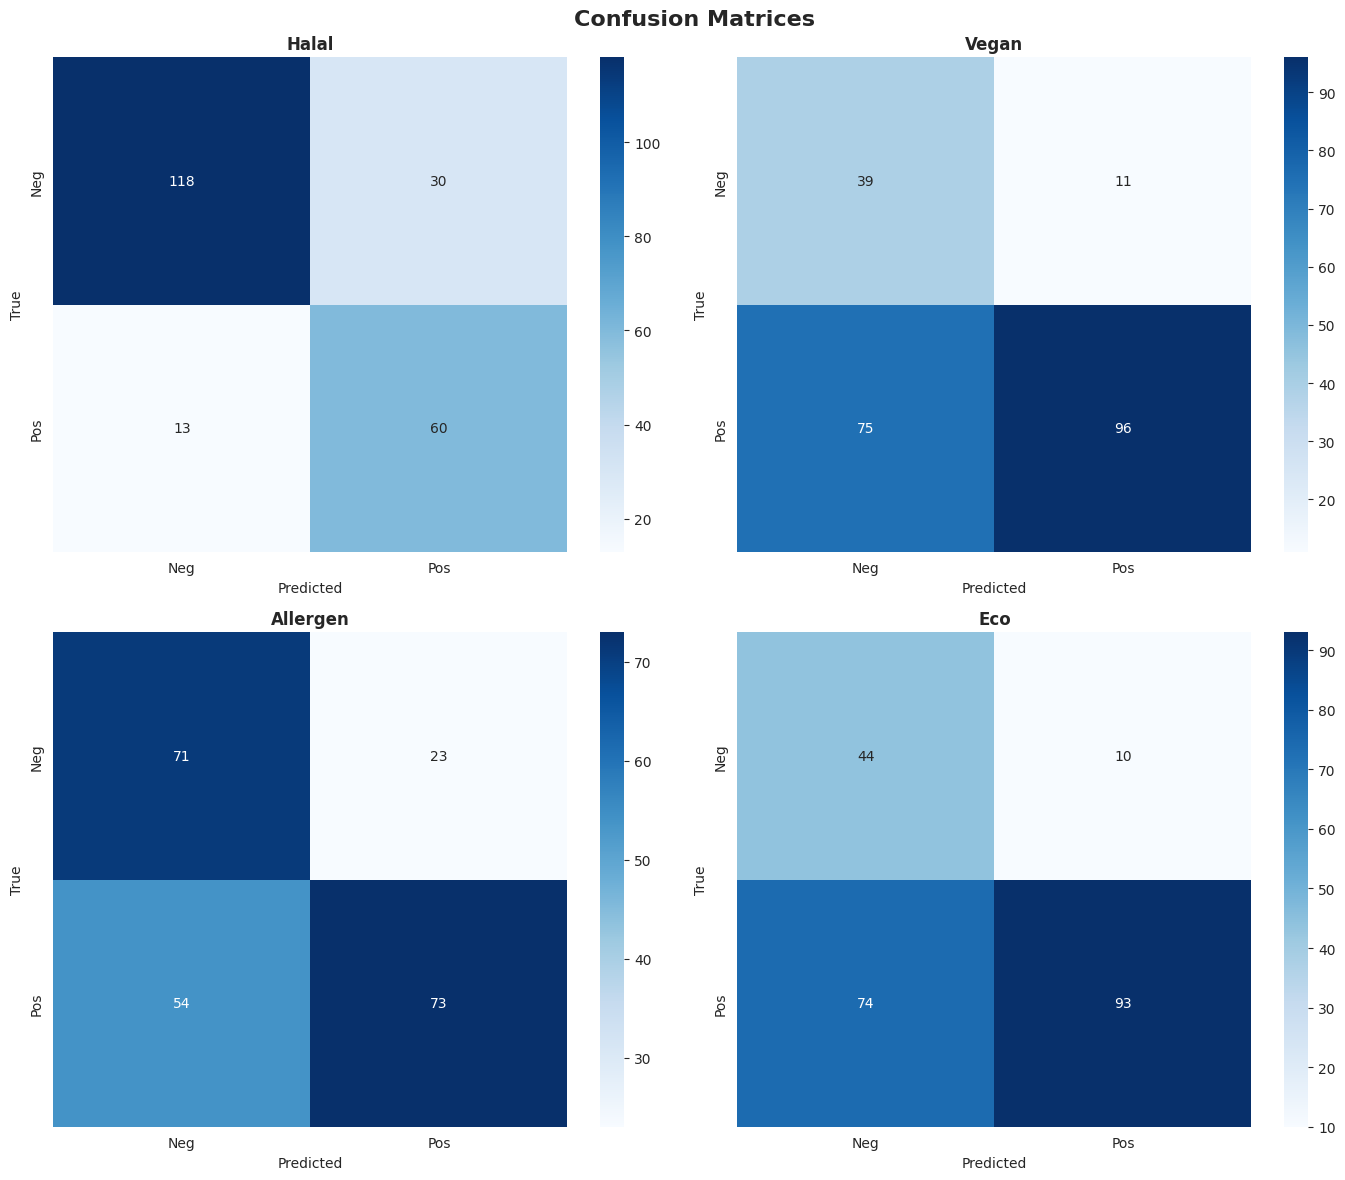

In [ ]:
# Confusion matrices
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('Confusion Matrices', fontsize=16, fontweight='bold')

for idx, (label_name, ax) in enumerate(zip(label_names, axes.flat)):
    cm = confusion_matrix(test_labels[:, idx], test_preds_binary[:, idx])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Neg', 'Pos'],
                yticklabels=['Neg', 'Pos'])
    ax.set_title(f'{label_name}', fontweight='bold')
    ax.set_ylabel('True')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.show()

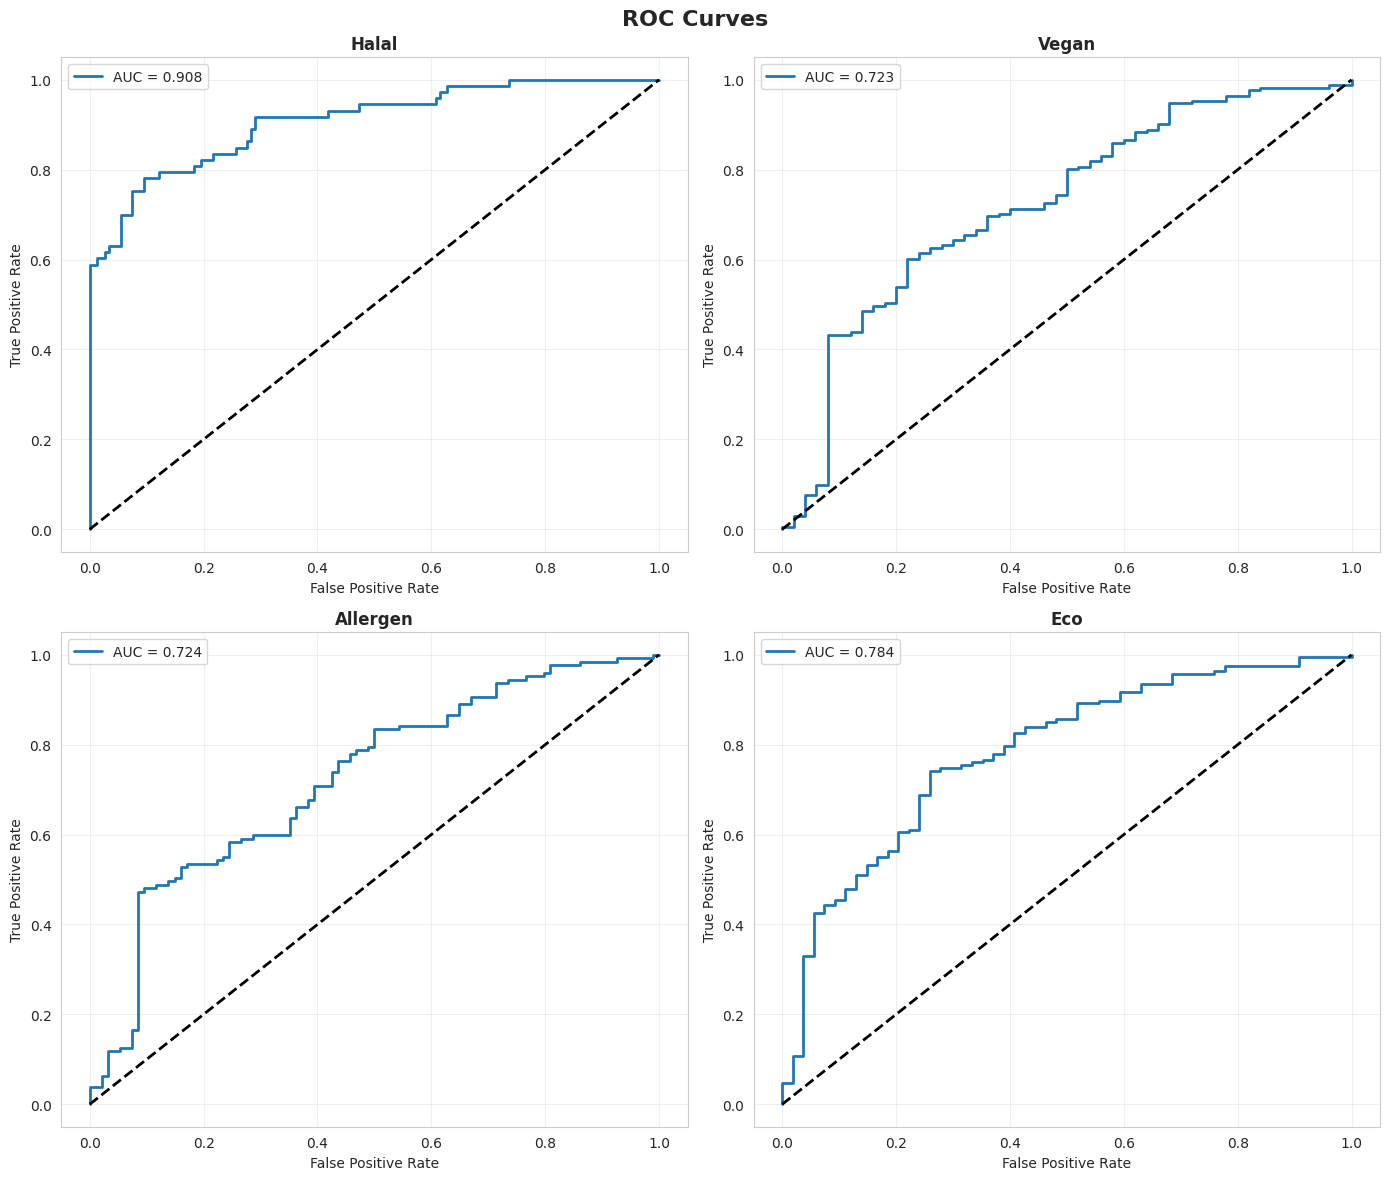

In [ ]:
# ROC curves
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('ROC Curves', fontsize=16, fontweight='bold')

for idx, (label_name, ax) in enumerate(zip(label_names, axes.flat)):
    fpr, tpr, _ = roc_curve(test_labels[:, idx], test_preds[:, idx])
    roc_auc = auc(fpr, tpr)

    ax.plot(fpr, tpr, lw=2, label=f'AUC = {roc_auc:.3f}')
    ax.plot([0, 1], [0, 1], 'k--', lw=2)
    ax.set_title(f'{label_name}', fontweight='bold')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# TEST

In [ ]:
# Enhanced Prediction Function
def predict_ingredients(ingredient_text: str, verbose=True):
    """
    Predict classifications for ingredient list

    Args:
        ingredient_text: Comma-separated ingredient list
        verbose: Print detailed results

    Returns:
        Dictionary with predictions for each label
    """
    # Preprocess
    clean_text = clean_ingredient_text(ingredient_text)
    ing_list = extract_ingredients(clean_text)

    if verbose:
        print(f"📝 Input: {ingredient_text}")
        print(f"🧪 Detected {len(ing_list)} ingredients\n")

    # Extract KG features
    kg_feat = kg.extract_features(ing_list)

    # Tokenize
    encoding = tokenizer(
        clean_text,
        max_length=256,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )

    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)
    kg_tensor = torch.tensor([kg_feat], dtype=torch.float32).to(device)

    # Predict
    model.eval()
    with torch.no_grad():
        logits = model(input_ids, attention_mask, kg_tensor)
        probs = torch.sigmoid(logits).cpu().numpy()[0]

    # Format results
    results = {}
    label_list = ['Halal', 'Vegan', 'Allergen-Safe', 'Eco-Friendly']

    if verbose:
        print("="*70)
        print("🎯 PREDICTIONS")
        print("="*70 + "\n")

    for i, label in enumerate(label_list):
        prob = float(probs[i])
        prediction = 'Positive' if prob > 0.5 else 'Negative'
        confidence = abs(prob - 0.5) * 2

        results[label] = {
            'prediction': prediction,
            'probability': round(prob, 4),
            'confidence': round(confidence, 4)
        }

        if verbose:
            emoji = "✅" if prediction == 'Positive' else "❌"
            conf_flag = "⚠️ LOW CONFIDENCE" if confidence < 0.5 else ""

            print(f"{emoji} {label:20s}: {prediction:8s} "
                  f"(prob: {prob:.1%}, conf: {confidence:.1%}) ")

    if verbose:
        print("\n" + "="*70 + "\n")

    return results

print("✅ Enhanced prediction function ready!")


# ========================================
#             INPUT LOADER
# ========================================
results_1 = predict_ingredients("water, glycerin, niacinamide, hyaluronic acid, tocopherol")
print(results_1)

✅ Enhanced prediction function ready!
📝 Input: water, glycerin, niacinamide, hyaluronic acid, tocopherol
🧪 Detected 5 ingredients

🎯 PREDICTIONS

✅ Halal               : Positive (prob: 72.5%, conf: 45.0%) 
✅ Vegan               : Positive (prob: 73.2%, conf: 46.3%) 
✅ Allergen-Safe       : Positive (prob: 65.1%, conf: 30.2%) 
✅ Eco-Friendly        : Positive (prob: 68.8%, conf: 37.5%) 


{'Halal': {'prediction': 'Positive', 'probability': 0.7251, 'confidence': 0.4503}, 'Vegan': {'prediction': 'Positive', 'probability': 0.7316, 'confidence': 0.4632}, 'Allergen-Safe': {'prediction': 'Positive', 'probability': 0.6508, 'confidence': 0.3017}, 'Eco-Friendly': {'prediction': 'Positive', 'probability': 0.6877, 'confidence': 0.3754}}


In [ ]:
results_1 = predict_ingredients("100% Unrefined Sclerocraya Birrea (Marula) Kernel Oil.")
print(results_1)

📝 Input: 100% Unrefined Sclerocraya Birrea (Marula) Kernel Oil.
🧪 Detected 1 ingredients

🎯 PREDICTIONS

✅ Halal               : Positive (prob: 73.7%, conf: 47.5%) 
✅ Vegan               : Positive (prob: 72.6%, conf: 45.2%) 
✅ Allergen-Safe       : Positive (prob: 65.0%, conf: 30.1%) 
✅ Eco-Friendly        : Positive (prob: 67.5%, conf: 35.0%) 


{'Halal': {'prediction': 'Positive', 'probability': 0.7374, 'confidence': 0.4747}, 'Vegan': {'prediction': 'Positive', 'probability': 0.7258, 'confidence': 0.4516}, 'Allergen-Safe': {'prediction': 'Positive', 'probability': 0.6504, 'confidence': 0.3008}, 'Eco-Friendly': {'prediction': 'Positive', 'probability': 0.6752, 'confidence': 0.3504}}
